# Analiza jakości danych w systemie

## 1. Wprowadzenie

### 1.1 Cel analizy

Celem niniejszej analizy jest ocena jakości danych zgromadzonych w hurtowni oraz identyfikacja potencjalnych problemów mogących wpłynąć na wiarygodność prowadzonych analiz.

### 1.2 Zakres analizy

Analiza obejmuje dane z sezonów 2007/2008 - 2025/2026, z 50 lig piłkarskich z 25 krajów. Sezon 2025/2026 jest traktowany jako sezon bieżący i nie jest uwzględniany w analizach kompletności.

### 1.3 Metodologia

Przedstawione analizy opierają się na danych pobranych zarówno ze znormalizowanej części hurtowni jak i w niektórych przypadkach z systemu źródłowego. Do weryfikacji jakości wykorzystano zestaw metryk obejmujących kompletność, spójność oraz poprawność danych.

### 1.4 Konfiguracja

In [232]:
from sqlalchemy import create_engine, text
import urllib
from sqlalchemy import inspect
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [233]:
sns.set_palette("deep")

In [261]:
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=127.0.0.1,1433;"
    "DATABASE=LEAGUE_DB;"
    "UID=sa;"
    "PWD=YourStrongPassword1!;"
    "TrustServerCertificate=yes;"
)

source_engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    fast_executemany=True
)

source_inspector = inspect(source_engine)

In [ ]:
tables = source_inspector.get_table_names()
tables
# t = pd.read_sql("""SELECT TOP(20) * FROM dbo.T_F_Match_Stats""", source_engine)
# t.columns
# t = pd.read_sql("""
#     SELECT DISTINCT
#         m.home_team_name AS team_name,
#         ln.League_name AS league_name,
#         l.Country,
#         l.Division,
#         s.StartingYear,
#         s.EndingYear
#     FROM dbo.T_F_Match_Stats m
#     JOIN dbo.T_DIM_Season s ON s.SeasonSK = m.SeasonSK
#     JOIN dbo.T_DIM_League l ON l.League_id = m.Competition_id
#     JOIN dbo.T_DIM_League_name ln ON ln.Competition_id = l.League_id
# """, source_engine)
# t
# t = pd.read_sql("""SELECT * FROM dbo.ERR_LEAGUE""", source_engine)
# t


ProgrammingError: (pyodbc.ProgrammingError) ('42000', "[42000] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Could not find stored procedure 'dbo.P_process_files'. (2812) (SQLExecDirectW)")
[SQL: EXEC dbo.P_process_files]
(Background on this error at: https://sqlalche.me/e/20/f405)

In [236]:
def normalize_name(name: str) -> str:
    if not name:
        return None
    return name.strip().lower().replace("  ", " ")

def normalize_season_name(start, end) -> str:
    starting = int(start)
    ending = int(end)
    if starting == ending:
        ending += 1
    return f"{starting}/{ending}"

def load_teams_lookup(engine) -> dict:
    result = engine.execute(text("SELECT team_id, team_name, common_name FROM core.teams"))
    lookup = {}
    for row in result:
        if row.team_name:
            lookup[normalize_name(row.team_name)] = row.team_id
        if row.common_name:
            lookup[normalize_name(row.common_name)] = row.team_id
    return lookup

def load_leagues_lookup(engine) -> dict:
    result = engine.execute(text("SELECT league_id, name FROM core.leagues"))
    lookup = {}
    for row in result:
        if row.name:
            lookup[normalize_name(row.name)] = row.league_id
    return lookup

def load_seasons_lookup(engine) -> dict:
    result = engine.execute(text("SELECT season_id, name FROM core.seasons"))
    lookup = {}
    for row in result:
        if row.name:
            lookup[row.name] = row.season_id
    return lookup



In [237]:
# missing = {"team": 0, "league": 0, "season": 0}
# def test(df):    
#     inserted_rows = 0
#     engine = create_engine(
#         f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:"
#         f"{os.environ['POSTGRES_PASSWORD']}@localhost:{os.environ['POSTGRES_PORT']}/"
#         f"{os.environ['POSTGRES_DB']}"
#     )

#     with engine.begin() as connection:
#         team_lookup = load_teams_lookup(connection)
#         league_lookup = load_leagues_lookup(connection)
#         season_lookup = load_seasons_lookup(connection)

#         for _, row in df.iterrows():
#             team_id = team_lookup.get(normalize_name(row.get("team_name")))
#             league_id = league_lookup.get(normalize_name(row.get("league_name")))
#             season_id = season_lookup.get(
#                 normalize_season_name(row.get("StartingYear"), row.get("EndingYear"))
#             )

#             if not team_id:
#                 missing["team"] += 1
#                 print(normalize_name((row.get("team_name"))))
#             if not league_id:
#                 missing["league"] += 1
#             if not season_id:
#                 missing["season"] += 1
#             if not team_id or not league_id or not season_id:
#                 continue

#             connection.execute(
#                 text("""
#                     INSERT INTO core.teams_leagues_seasons(
#                         team_id, 
#                         league_id, 
#                         season_id
#                     ) VALUES (
#                         :team_id, 
#                         :league_id, 
#                         :season_id
#                     )
#                     ON CONFLICT (team_id, season_id, league_id) DO NOTHING
#                 """),
#                 {
#                     "team_id": team_id,
#                     "league_id": league_id,
#                     "season_id": season_id
#                 }
#             )
#             inserted_rows += 1

#     return inserted_rows

# test(t)
# print(missing)

In [238]:
destination_engine = create_engine(f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:" \
    f"{os.environ['POSTGRES_PASSWORD']}@localhost:{os.environ['POSTGRES_PORT']}" \
    f"/{os.environ['POSTGRES_DB']}"
)

In [239]:
leagues = pd.read_sql("""
    SELECT * FROM core.teams;
""", destination_engine)
leagues

,team_id,team_name,common_name,home_stadium
0,32fa4538-1ec7-4656-a6a0-99e1259d9bcf,Unknown,Unknown,None
1,076b2545-0048-42ab-8a10-504bfa2b1af8,Hapoel Be'er Sheva FC,Hapoel Be'er Sheva FC,None
2,e418faed-a8a6-415d-9ebe-a41ecf422aba,Hapoel Be'er Sheva FC,Hapoel Be'er Sheva FC,None
3,5c9c9832-d8dd-4174-8e46-84529b67b8dd,Hapoel Be'er Sheva FC,Hapoel Be'er Sheva FC,None
4,8b81484d-6fe6-4437-93a2-a24a0fa00d17,Hapoel Be'er Sheva FC,Hapoel Be'er Sheva FC,None
...,...,...,...,...
2332,d595cec2-a396-4348-9c66-821165543df0,Baku Sportinq FK,Baku Sportinq FK,None
2333,adb1ced5-6c56-45ab-be4f-35a93fc2151a,Baku Sportinq FK,Baku Sportinq FK,None
2334,386f8bde-b299-444b-abfb-b6e91ddec495,SU Dinamo Jug,SU Dinamo Jug,None
2335,d2cafb4a-8116-464e-a3dd-5002144d99f0,Asteras Tripolis II,Asteras Tripolis II,None


## 2. Kompletność danych historycznych

### 2.1 Ogólna charakterystyka zbioru danych

/var/folders/3n/fyvxsgkx047335892dh0sh940000gn/T/ipykernel_3358/2533189058.py:74: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


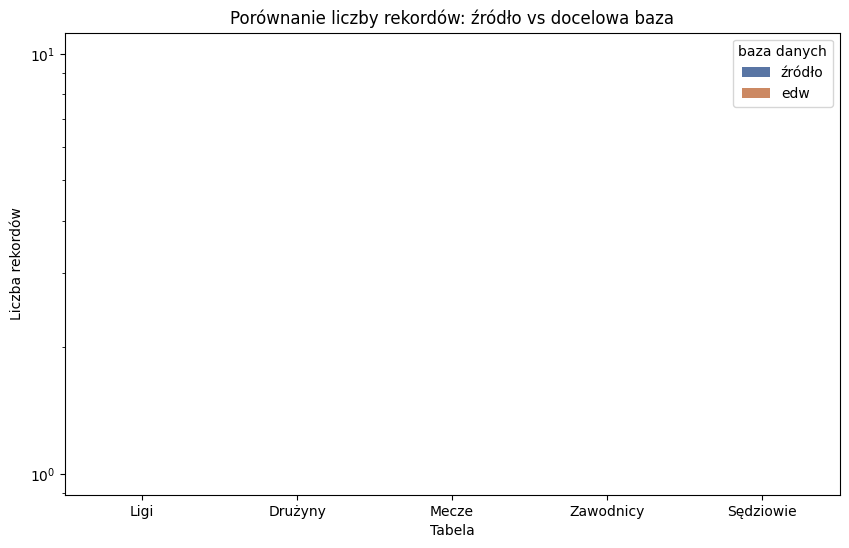

In [ ]:
sl_query = 'SELECT COUNT(*) FROM dbo.T_DIM_League;'
sl_df = pd.read_sql(sl_query, source_engine)
sl_count = sl_df.iloc[0, 0]

dl_query = 'SELECT COUNT(*) FROM core.leagues;'
dl_df = pd.read_sql(dl_query, destination_engine)
dl_count = dl_df.iloc[0, 0]

sm_query = 'SELECT COUNT(*) FROM dbo.T_F_Match_Stats;'
sm_df = pd.read_sql(sm_query, source_engine)
sm_count = sm_df.iloc[0, 0]

dm_query = 'SELECT COUNT(*) FROM core.matches;'
dm_df = pd.read_sql(dm_query, destination_engine)
dm_count = dm_df.iloc[0, 0]

st_query = 'SELECT COUNT(*) FROM dbo.T_DIM_Team;'
st_df = pd.read_sql(st_query, source_engine)
st_count = st_df.iloc[0, 0]

dt_query = 'SELECT COUNT(*) FROM core.teams;'
dt_df = pd.read_sql(dt_query, destination_engine)
dt_count = dt_df.iloc[0, 0]

sp_query = 'SELECT COUNT(*) FROM dbo.T_DIM_Player;'
sp_df = pd.read_sql(sp_query, source_engine)
sp_count = sp_df.iloc[0, 0]

dp_query = 'SELECT COUNT(*) FROM core.players;'
dp_df = pd.read_sql(dp_query, destination_engine)
dp_count = dp_df.iloc[0, 0]

sr_query = 'SELECT COUNT(*) FROM dbo.T_DIM_Referees;'
sr_df = pd.read_sql(sr_query, source_engine)
sr_count = sr_df.iloc[0, 0]

dr_query = 'SELECT COUNT(*) FROM core.referees;'
dr_df = pd.read_sql(dr_query, destination_engine)
dr_count = dr_df.iloc[0, 0]

plot_df = pd.DataFrame([
    { 
        "tabela": "Ligi",
        "źródło": sl_count,
        "edw": dl_count
    },
    { 
        "tabela": "Drużyny",
        "źródło": st_count,
        "edw": dt_count
    },
    { 
        "tabela": "Mecze",
        "źródło": sm_count,
        "edw": dm_count
    },
    { 
        "tabela": "Zawodnicy",
        "źródło": sp_count,
        "edw": dp_count
    },
    { 
        "tabela": "Sędziowie",
        "źródło": sr_count,
        "edw": dr_count
    }
])

plot_long = plot_df.melt(id_vars="tabela", value_vars=["źródło", "edw"], 
                         var_name="baza danych", value_name="liczba_rekordów")

plt.figure(figsize=(10,6))
ax = sns.barplot(data=plot_long, x="tabela", y="liczba_rekordów", hue="baza danych")
plt.yscale("log")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, rotation=0)

plt.title("Porównanie liczby rekordów: źródło vs docelowa baza")
plt.ylabel("Liczba rekordów")
plt.xlabel("Tabela")
plt.show()


In [241]:
source_date_range_query = """
SELECT 
    MIN(DateSK) AS source_min_date, 
    MAX(DateSK) AS source_max_date
FROM 
    dbo.T_F_Match_Stats;
"""
sdr_df = pd.read_sql(source_date_range_query, source_engine)

destination_date_range_query = """
SELECT 
    MIN(date) AS destination_min_date, 
    MAX(date) AS destination_max_date
FROM 
    core.matches;
"""
ddr_df = pd.read_sql(destination_date_range_query, destination_engine)

df = pd.concat([sdr_df, ddr_df], axis=1)
df


,source_min_date,source_max_date,destination_min_date,destination_max_date
0,19000101,19000101,1900-01-01,1900-01-01


In [242]:
source_unique_seasons = """
SELECT 
    COUNT(DISTINCT(SeasonSK)) AS source_season_count
FROM 
    dbo.T_F_Match_Stats;
""" 
sus_df = pd.read_sql(source_unique_seasons, source_engine)

destination_unique_seasons = """
SELECT 
    COUNT(*) AS destination_season_count
FROM 
    core.seasons;
""" 
dus_df = pd.read_sql(destination_unique_seasons, destination_engine)


df = pd.DataFrame({
    "source_season_count": [sus_df.iloc[0, 0]],
    "destination_season_count": [dus_df.iloc[0, 0]],
})
df

,source_season_count,destination_season_count
0,36,21


In [243]:
source_unique_leagues = """
SELECT 
    COUNT(DISTINCT(LeagueName)) AS source_unique_leagues_count
FROM 
    dbo.T_DIM_League;
""" 
sul_df = pd.read_sql(source_unique_leagues, source_engine)

destination_unique_leagues = """
SELECT 
    COUNT(*) AS destination_unique_leagues_count
FROM 
    core.leagues;
""" 
dul_df = pd.read_sql(destination_unique_leagues, destination_engine)

df = pd.DataFrame({
    "source_unique_leagues_count": [sul_df.iloc[0, 0]],
    "destination_unique_leagues_count": [dul_df.iloc[0, 0]],
})
df

,source_unique_leagues_count,destination_unique_leagues_count
0,26,45


### 2.2 Pokrycie sezonów

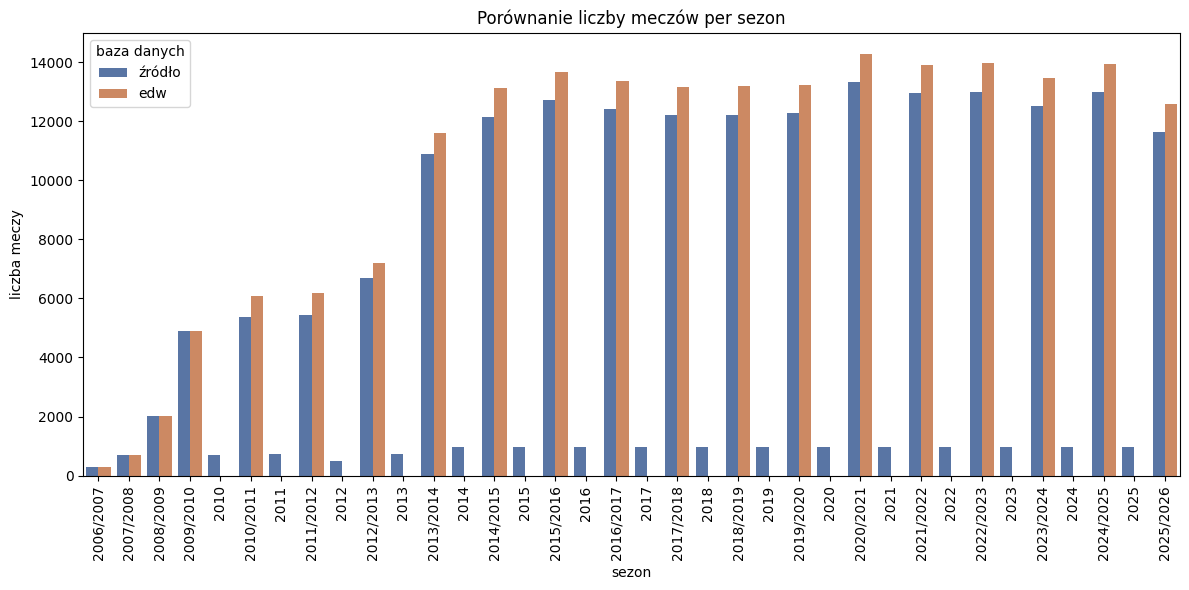

In [244]:
source_matches_per_season = """
    SELECT 
        s.SeasonName AS sezon,
        COUNT(ms.MatchSK) AS źródło
    FROM
        dbo.T_F_Match_Stats ms
    JOIN 
        dbo.T_DIM_Season s ON ms.SeasonSK = s.SeasonSK
    GROUP BY
        s.SeasonName;
"""
smps_df = pd.read_sql(source_matches_per_season, source_engine)

destination_matches_per_season = """
    SELECT 
        s.name AS sezon,
        COUNT(m.match_id) AS edw
    FROM
        core.matches m
    JOIN 
        core.seasons s ON s.season_id = m.season_id 
    GROUP BY
        s.name;
"""
dmps_df = pd.read_sql(destination_matches_per_season, destination_engine)

df = pd.merge(smps_df, dmps_df, on="sezon", how="outer")

plot_df = df.melt(id_vars="sezon", value_vars=["źródło", "edw"], 
                  var_name="baza danych", value_name="liczba meczy")

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="sezon", y="liczba meczy", hue="baza danych")
plt.xticks(rotation=90)
plt.title("Porównanie liczby meczów per sezon")
plt.tight_layout()
plt.show()


### 2.3 Pokrycie lig

In [245]:
source_matches_per_league = """
    SELECT 
        ln.League_name AS liga,
        COUNT(m.MatchSK) AS źródło
    FROM
        dbo.T_F_Match_Stats m
    JOIN
        dbo.T_DIM_League l ON l.League_id = m.competition_id
    JOIN
        dbo.T_DIM_League_name ln ON ln.competition_id = m.competition_id
    GROUP BY
        ln.League_name;
"""
smpl_df = pd.read_sql(source_matches_per_league, source_engine)

destination_matches_per_league = """
    SELECT
        l.name AS liga,
        COUNT(DISTINCT m.match_id) AS edw
    FROM core.matches m
    JOIN core.teams_leagues_seasons tls
        ON tls.team_id = m.home_team_id
        AND tls.season_id = m.season_id
    JOIN core.leagues l
    ON l.league_id = tls.league_id
    GROUP BY l.name;
"""
dmpl_df = pd.read_sql(destination_matches_per_league, destination_engine)

df = pd.merge(
    smpl_df,
    dmpl_df,
    on="liga",
    how="outer"
).fillna(0)

df[["źródło", "edw"]] = df[["źródło", "edw"]].astype(int)

plot_df = df.melt(
    id_vars="liga",
    value_vars=["źródło", "edw"],
    var_name="baza danych",
    value_name="liczba meczów"
)

league_order = (
    df.assign(max_cnt=df[["źródło", "edw"]].max(axis=1))
      .sort_values("max_cnt", ascending=False)["liga"]
      .tolist()
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_df,
    x="liga",
    y="liczba meczów",
    hue="baza danych",
    order=league_order
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Liczba meczów")
plt.xlabel("Liga")
plt.title("Porównanie liczby meczów per liga")
plt.legend(title="Baza danych")
plt.tight_layout()
plt.show()
dmpl_df

ProgrammingError: (pyodbc.ProgrammingError) ('42S22', "[42S22] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Invalid column name 'League_id'. (207) (SQLExecDirectW)")
[SQL: 
    SELECT 
        ln.League_name AS liga,
        COUNT(m.MatchSK) AS źródło
    FROM
        dbo.T_F_Match_Stats m
    JOIN
        dbo.T_DIM_League l ON l.League_id = m.competition_id
    JOIN
        dbo.T_DIM_League_name ln ON ln.competition_id = m.competition_id
    GROUP BY
        ln.League_name;
]
(Background on this error at: https://sqlalche.me/e/20/f405)